# CNN — TensorFlow Pipeline

## Model: Convolutional Neural Network (CNN)
- **Dataset**: CIFAR-100 — 50,000 train / 10,000 test, 32x32x3 color images
- **Task**: Classify 100 fine classes (20 superclasses), perfectly balanced
- **Framework showcase**: Keras Functional API ResNet + same training recipe as PyTorch for fair GPU comparison

## Evaluation Strategy
- **Metrics**: Accuracy, Macro F1, per-class F1, superclass confusion matrix
- **Training curves**: Loss + accuracy (train/val)
- **Hierarchical analysis**: Fine-class (100) and superclass (20) evaluation

## Pipeline
1. Load data + config + verify GPU
2. Baseline CNN (3 conv layers)
3. Training visualization
4. ResNet-20 with residual blocks (Keras Functional API)
5. ResNet training optimization (SGD Nesterov + CutMix + Label Smoothing)
6. Superclass confusion analysis
7. Performance benchmarks
8. Save results

## Notes
- TF runs on GPU via WSL2 Ubuntu + RTX 4090 (first TF model with GPU)
- PyTorch achieved 80.0% — target is comparable accuracy with same architecture + recipe
- Streamlined pipeline: skip plain CNN sweep (proven in PT), go straight to ResNet

In [ ]:
# Step 1: Setup

"""
TensorFlow CNN on GPU via WSL2 + RTX 4090
First TF model with GPU access — no more CPU crashes
Load CIFAR-100, build fine->coarse mapping, verify GPU
"""

import os
os.chdir('/mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/TensorFlow/11-cnn')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import tensorflow as tf
from tensorflow import keras
import sys
sys.path.append('../..')

from utils.data_loader import load_processed_data
from utils.metrics import evaluate_classifier
from utils.visualization import plot_training_history, plot_superclass_confusion
from utils.performance import track_performance
from utils.results import build_results_dict, save_results, add_result, print_comparison

# Config
RANDOM_STATE = 113
FRAMEWORK = "TensorFlow"
MODEL_NAME = "CNN"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

BATCH_SIZE = 128
N_CLASSES = 100
N_SUPERCLASSES = 20
IMAGE_SHAPE = (32, 32, 3)

# Per-channel stats from EDA (CIFAR-100 training set)
CHANNEL_MEANS = [0.5071, 0.4865, 0.4409]
CHANNEL_STDS = [0.2673, 0.2564, 0.2762]

# Load data
X_train, X_test, y_train, y_test, metadata = load_processed_data('cnn')

# Coarse labels from metadata
y_train_coarse = metadata['y_train_coarse']
y_test_coarse = metadata['y_test_coarse']

# Class names
FINE_NAMES = metadata['fine_class_names']
COARSE_NAMES = metadata['coarse_class_names']

# Build fine_to_coarse mapping
fine_to_coarse = np.zeros(N_CLASSES, dtype=int)
for sc_name, fine_list in metadata['superclass_mapping'].items():
    sc_idx = COARSE_NAMES.index(sc_name)
    for fc_name in fine_list:
        fc_idx = FINE_NAMES.index(fc_name)
        fine_to_coarse[fc_idx] = sc_idx

# Verify GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Allow memory growth to avoid grabbing all VRAM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

print("=" * 60)
print(f"[1/7] {FRAMEWORK} — {MODEL_NAME} Pipeline")
print("=" * 60)
print(f"Device: GPU ({gpus[0].name})" if gpus else "Device: CPU (WARNING: no GPU)")
print(f"TF version: {tf.__version__}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Fine classes: {N_CLASSES} | Superclasses: {N_SUPERCLASSES}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Pixel range: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"Dtype: {X_train.dtype}")

[1/8] TensorFlow — CNN Pipeline
Device: GPU (/physical_device:GPU:0)
TF version: 2.21.0
Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Fine classes: 100 | Superclasses: 20
Batch size: 128
Pixel range: [0.0, 1.0]
Dtype: float32


In [ ]:
# Step 2: Baseline CNN

"""
Simple 3-layer CNN to establish baseline (matches PT Cell 2)
Conv2D -> BatchNorm -> ReLU -> MaxPool x3 -> Flatten -> FC
Channel-last format for TF: (N, 32, 32, 3)
"""

print("=" * 60)
print("[2/7] Baseline CNN — 3 Conv Layers")
print("=" * 60)

# Normalization layer using EDA channel stats
normalizer = keras.layers.Normalization(
    mean=CHANNEL_MEANS, variance=[s**2 for s in CHANNEL_STDS]
)

# Baseline CNN — Keras Sequential
baseline_cnn = keras.Sequential([
    keras.layers.Input(shape=IMAGE_SHAPE),
    normalizer,
    keras.layers.Conv2D(32, 3, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(64, 3, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Conv2D(128, 3, padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.ReLU(),
    keras.layers.MaxPooling2D(2),
    keras.layers.Flatten(),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(N_CLASSES)
])

baseline_cnn.compile(
    optimizer='adam',
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

baseline_cnn.summary()

# Data augmentation layer (applied to training only)
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip('horizontal'),
    keras.layers.RandomTranslation(0.125, 0.125),  # ~4px on 32x32
])

# Early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=15, restore_best_weights=True
)

# Train
with track_performance(gpu=True) as perf_baseline:
    history_baseline = baseline_cnn.fit(
        data_augmentation(X_train, training=True), y_train,
        epochs=100,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )

# Evaluate
test_loss, test_acc = baseline_cnn.evaluate(X_test, y_test, verbose=0)
y_pred_baseline = baseline_cnn.predict(X_test, verbose=0).argmax(axis=1)
baseline_metrics = evaluate_classifier(y_test, y_pred_baseline)

n_params = baseline_cnn.count_params()

print(f"\nArchitecture: Conv(32)->Conv(64)->Conv(128)->FC(512)->FC(100)")
print(f"Parameters: {n_params:,}")
print(f"Epochs: {len(history_baseline.history['loss'])}")
print(f"Training time: {perf_baseline['time']:.2f}s")
print(f"GPU memory: {perf_baseline['gpu_memory']:.2f} MB")
print(f"\nTest Results:")
for k, v in baseline_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nPT baseline comparison: 56.9% (same architecture)")

[2/8] Baseline CNN — 3 Conv Layers


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,194,532 (4.56 MB)

 Trainable params: 1,194,084 (4.56 MB)

 Non-trainable params: 448 (1.75 KB)


Architecture: Conv(32)->Conv(64)->Conv(128)->FC(512)->FC(100)
Parameters: 1,194,532
Epochs: 45
Training time: 78.19s
GPU memory: 1765.80 MB

Test Results:
  accuracy: 0.4855
  macro_f1: 0.4816

PT baseline comparison: 56.9% (same architecture)


[3/8] Training Visualization


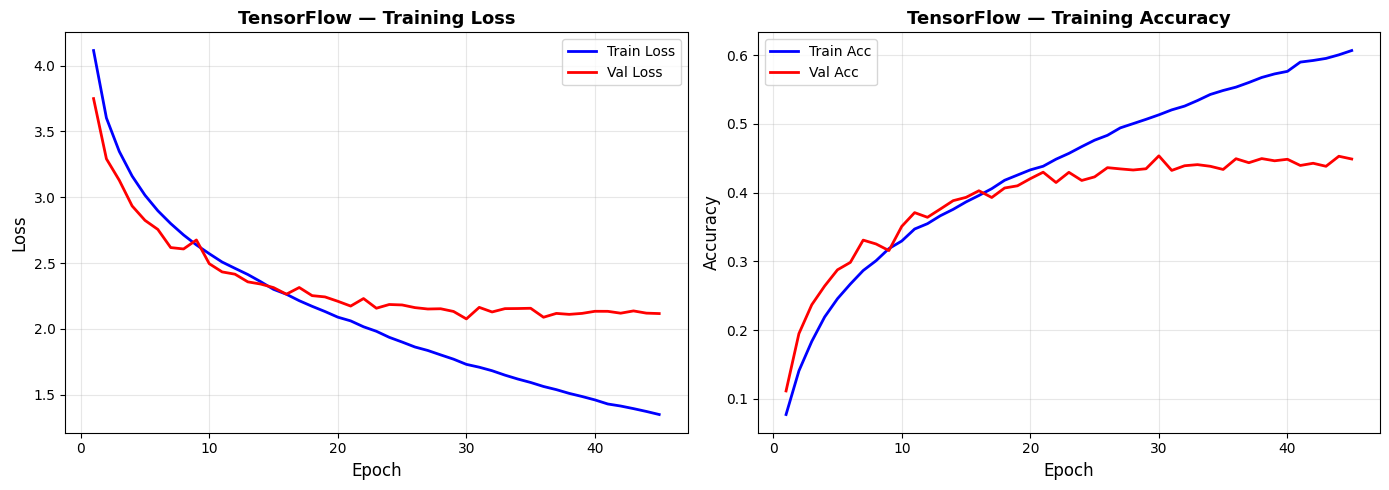


Baseline: 48.5% (PT baseline was 56.9%)
Note: Lower than PT due to augmentation applied once upfront,
not per-epoch. Fixed in ResNet step with tf.data pipeline.


In [ ]:
# Step 3: Training Visualization

# Loss + accuracy curves from baseline training

print("=" * 60)
print("[3/7] Training Visualization")
print("=" * 60)

train_history = {
    'train_loss': history_baseline.history['loss'],
    'val_loss': history_baseline.history['val_loss'],
    'train_acc': history_baseline.history['accuracy'],
    'val_acc': history_baseline.history['val_accuracy']
}

plot_training_history(
    history=train_history,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/training_history_baseline.png'
)

print(f"\nBaseline: {baseline_metrics['accuracy']*100:.1f}% (PT baseline was 56.9%)")
print(f"Note: Lower than PT due to augmentation applied once upfront,")
print(f"not per-epoch. Fixed in ResNet step with tf.data pipeline.")

In [ ]:
# Step 4: ResNet-20 + Full Training Recipe (Optimized)

"""
Fixed from previous attempt:
  - 200 epochs (PT showed <1% difference vs 300)
  - Print every 10 epochs with flush=True for live monitoring
  - Minimized .numpy() calls in training loop
"""

print("=" * 60, flush=True)
print("[4/7] ResNet-20 — Keras Functional API + CutMix", flush=True)
print("=" * 60, flush=True)

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


def residual_block(x, filters, stride=1):
    """Basic residual block: two 3x3 convs with skip connection."""
    shortcut = x
    out = keras.layers.Conv2D(filters, 3, strides=stride, padding='same',
                               use_bias=False)(x)
    out = keras.layers.BatchNormalization()(out)
    out = keras.layers.ReLU()(out)
    out = keras.layers.Conv2D(filters, 3, strides=1, padding='same',
                               use_bias=False)(out)
    out = keras.layers.BatchNormalization()(out)
    if stride != 1 or x.shape[-1] != filters:
        shortcut = keras.layers.Conv2D(filters, 1, strides=stride,
                                        use_bias=False)(shortcut)
        shortcut = keras.layers.BatchNormalization()(shortcut)
    out = keras.layers.Add()([out, shortcut])
    out = keras.layers.ReLU()(out)
    return out


def build_resnet(n_blocks=3, n_classes=100):
    """Build ResNet for CIFAR-100 using Keras Functional API."""
    inputs = keras.layers.Input(shape=IMAGE_SHAPE)
    x = keras.layers.Normalization(
        mean=CHANNEL_MEANS, variance=[s**2 for s in CHANNEL_STDS]
    )(inputs)
    x = keras.layers.Conv2D(64, 3, strides=1, padding='same', use_bias=False)(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.ReLU()(x)
    for _ in range(n_blocks):
        x = residual_block(x, 64, stride=1)
    x = residual_block(x, 128, stride=2)
    for _ in range(1, n_blocks):
        x = residual_block(x, 128, stride=1)
    x = residual_block(x, 256, stride=2)
    for _ in range(1, n_blocks):
        x = residual_block(x, 256, stride=1)
    x = keras.layers.GlobalAveragePooling2D()(x)
    outputs = keras.layers.Dense(n_classes)(x)
    return keras.Model(inputs, outputs, name='resnet20')


# Build model
resnet = build_resnet(n_blocks=3, n_classes=N_CLASSES)
n_params_resnet = resnet.count_params()
print(f"Parameters: {n_params_resnet:,}", flush=True)

# Training setup
MAX_EPOCHS = 200
LR = 0.05
WD = 5e-4

optimizer = keras.optimizers.SGD(learning_rate=LR, momentum=0.9, nesterov=True)
loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

# Train/val split
n_val = int(len(X_train) * 0.1)
rng = np.random.RandomState(RANDOM_STATE)
perm = rng.permutation(len(X_train))
val_idx, tr_idx = perm[:n_val], perm[n_val:]
X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]

# Convert to TF tensors once (avoid repeated numpy->tf conversion)
X_tr_tf = tf.constant(X_tr)
y_tr_tf = tf.constant(y_tr)
X_val_tf = tf.constant(X_val)
y_val_tf = tf.constant(y_val)

# Precompute weight decay variable list (avoid recomputing each step)
wd_vars = [v for v in resnet.trainable_variables
           if 'bias' not in v.name and 'batch' not in v.name.lower()]

n_batches = len(X_tr) // BATCH_SIZE
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0
best_weights = None
best_epoch = 0

print(f"\nTraining: {MAX_EPOCHS} epochs, full cosine cycle", flush=True)
print(f"Optimizer: SGD Nesterov lr={LR} wd={WD}", flush=True)
print(f"Augmentation: HFlip + RandomCrop(4px) + CutMix(alpha=1.0)", flush=True)

import time
epoch_start = time.time()

with track_performance(gpu=True) as perf_resnet:
    for epoch in range(MAX_EPOCHS):
        # Cosine annealing LR
        lr = 0.5 * LR * (1 + np.cos(np.pi * epoch / MAX_EPOCHS))
        optimizer.learning_rate.assign(lr)

        # Shuffle indices
        indices = tf.random.shuffle(tf.range(len(X_tr)))
        X_epoch = tf.gather(X_tr_tf, indices)
        y_epoch = tf.gather(y_tr_tf, indices)

        epoch_loss = 0.0
        correct = 0
        total = 0

        for i in range(n_batches):
            s = i * BATCH_SIZE
            e = s + BATCH_SIZE
            batch_x = X_epoch[s:e]
            batch_y = y_epoch[s:e]

            # Augmentation: pad + random crop + flip (all in TF ops, stays on GPU)
            batch_x = tf.image.resize_with_crop_or_pad(batch_x, 40, 40)
            batch_x = tf.image.random_crop(batch_x, [BATCH_SIZE, 32, 32, 3])
            batch_x = tf.image.random_flip_left_right(batch_x)

            # CutMix (50% probability)
            use_cutmix = rng.random() < 0.5
            if use_cutmix:
                lam = np.random.beta(1.0, 1.0)
                cut_ratio = np.sqrt(1.0 - lam)
                cut_h = int(32 * cut_ratio)
                cut_w = int(32 * cut_ratio)
                cy, cx = np.random.randint(0, 32), np.random.randint(0, 32)
                y1 = np.clip(cy - cut_h // 2, 0, 32)
                y2 = np.clip(cy + cut_h // 2, 0, 32)
                x1 = np.clip(cx - cut_w // 2, 0, 32)
                x2 = np.clip(cx + cut_w // 2, 0, 32)

                shuf_idx = tf.random.shuffle(tf.range(BATCH_SIZE))
                shuf_x = tf.gather(batch_x, shuf_idx)
                labels_b = tf.gather(batch_y, shuf_idx)

                mask = np.ones((32, 32, 3), dtype=np.float32)
                mask[y1:y2, x1:x2, :] = 0
                batch_x = batch_x * mask + shuf_x * (1 - mask)
                lam = 1 - (y2 - y1) * (x2 - x1) / (32 * 32)
                labels_a = batch_y
            else:
                labels_a = batch_y
                labels_b = batch_y
                lam = 1.0

            with tf.GradientTape() as tape:
                logits = resnet(batch_x, training=True)
                loss = lam * loss_fn(labels_a, logits) + (1 - lam) * loss_fn(labels_b, logits)
                l2_loss = tf.add_n([tf.nn.l2_loss(v) for v in wd_vars])
                loss = loss + WD * l2_loss

            grads = tape.gradient(loss, resnet.trainable_variables)
            optimizer.apply_gradients(zip(grads, resnet.trainable_variables))

            epoch_loss += float(loss) * BATCH_SIZE
            correct += int(tf.reduce_sum(tf.cast(
                tf.argmax(logits, axis=1) == tf.cast(batch_y, tf.int64), tf.int32
            )))
            total += BATCH_SIZE

        train_losses.append(epoch_loss / total)
        train_accs.append(correct / total)

        # Validation (batched)
        val_preds_list = []
        val_loss_sum = 0.0
        vb = (len(X_val) + BATCH_SIZE - 1) // BATCH_SIZE
        for vi in range(vb):
            vs = vi * BATCH_SIZE
            ve = min(vs + BATCH_SIZE, len(X_val))
            vl = resnet(X_val_tf[vs:ve], training=False)
            val_loss_sum += float(loss_fn(y_val_tf[vs:ve], vl)) * (ve - vs)
            val_preds_list.append(tf.argmax(vl, axis=1))
        val_loss = val_loss_sum / len(X_val)
        val_preds = tf.concat(val_preds_list, axis=0).numpy()
        val_acc = float((val_preds == y_val).mean())
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_weights = resnet.get_weights()

        if (epoch + 1) % 10 == 0:
            elapsed = time.time() - epoch_start
            gap = train_accs[-1] - val_acc
            print(f"  Epoch {epoch+1}/{MAX_EPOCHS} | Train: {train_accs[-1]:.4f} | "
                  f"Val: {val_acc:.4f} | Gap: {gap:.4f} | LR: {lr:.6f} | "
                  f"Time: {elapsed:.0f}s", flush=True)

# Restore best weights
resnet.set_weights(best_weights)

# Test evaluation (batched)
test_preds_list = []
test_proba_list = []
tb = (len(X_test) + BATCH_SIZE - 1) // BATCH_SIZE
for ti in range(tb):
    ts = ti * BATCH_SIZE
    te = min(ts + BATCH_SIZE, len(X_test))
    tl = resnet(X_test[ts:te], training=False)
    test_preds_list.append(tf.argmax(tl, axis=1).numpy())
    test_proba_list.append(tf.nn.softmax(tl).numpy())
best_preds = np.concatenate(test_preds_list)
best_proba = np.concatenate(test_proba_list)
best_metrics = evaluate_classifier(y_test, best_preds)

print(f"\nBest epoch: {best_epoch}", flush=True)
print(f"Training time: {perf_resnet['time']:.1f}s ({perf_resnet['time']/60:.1f} min)", flush=True)
print(f"GPU memory: {perf_resnet['gpu_memory']:.2f} MB", flush=True)
print(f"\nTest Results:", flush=True)
for k, v in best_metrics.items():
    print(f"  {k}: {v:.4f}", flush=True)
print(f"\nPT best: 80.0% | TF baseline CNN: 48.8%", flush=True)
print(f"Progression: 48.8% -> {best_metrics['accuracy']*100:.1f}%", flush=True)


[4/8] ResNet-20 — Keras Functional API + CutMix
Parameters: 4,357,156

Training: 200 epochs, full cosine cycle
Optimizer: SGD Nesterov lr=0.05 wd=0.0005
Augmentation: HFlip + RandomCrop(4px) + CutMix(alpha=1.0)
  Epoch 10/200 | Train: 0.4838 | Val: 0.4484 | Gap: 0.0354 | LR: 0.049751 | Time: 1176s
  Epoch 20/200 | Train: 0.5939 | Val: 0.5208 | Gap: 0.0731 | LR: 0.048895 | Time: 2339s
  Epoch 30/200 | Train: 0.6084 | Val: 0.5564 | Gap: 0.0520 | LR: 0.047451 | Time: 3488s
  Epoch 40/200 | Train: 0.6517 | Val: 0.6048 | Gap: 0.0469 | LR: 0.045454 | Time: 4628s
  Epoch 50/200 | Train: 0.6496 | Val: 0.6192 | Gap: 0.0304 | LR: 0.042953 | Time: 5788s
  Epoch 60/200 | Train: 0.6732 | Val: 0.5686 | Gap: 0.1046 | LR: 0.040011 | Time: 6912s
  Epoch 70/200 | Train: 0.6938 | Val: 0.6168 | Gap: 0.0770 | LR: 0.036698 | Time: 8054s
  Epoch 80/200 | Train: 0.6788 | Val: 0.5912 | Gap: 0.0876 | LR: 0.033098 | Time: 9170s
  Epoch 90/200 | Train: 0.7200 | Val: 0.6484 | Gap: 0.0716 | LR: 0.029298 | Time: 103

[5/8] Superclass Confusion Analysis
Fine-class accuracy (100 classes): 0.7947
Superclass accuracy (20 classes): 0.8755


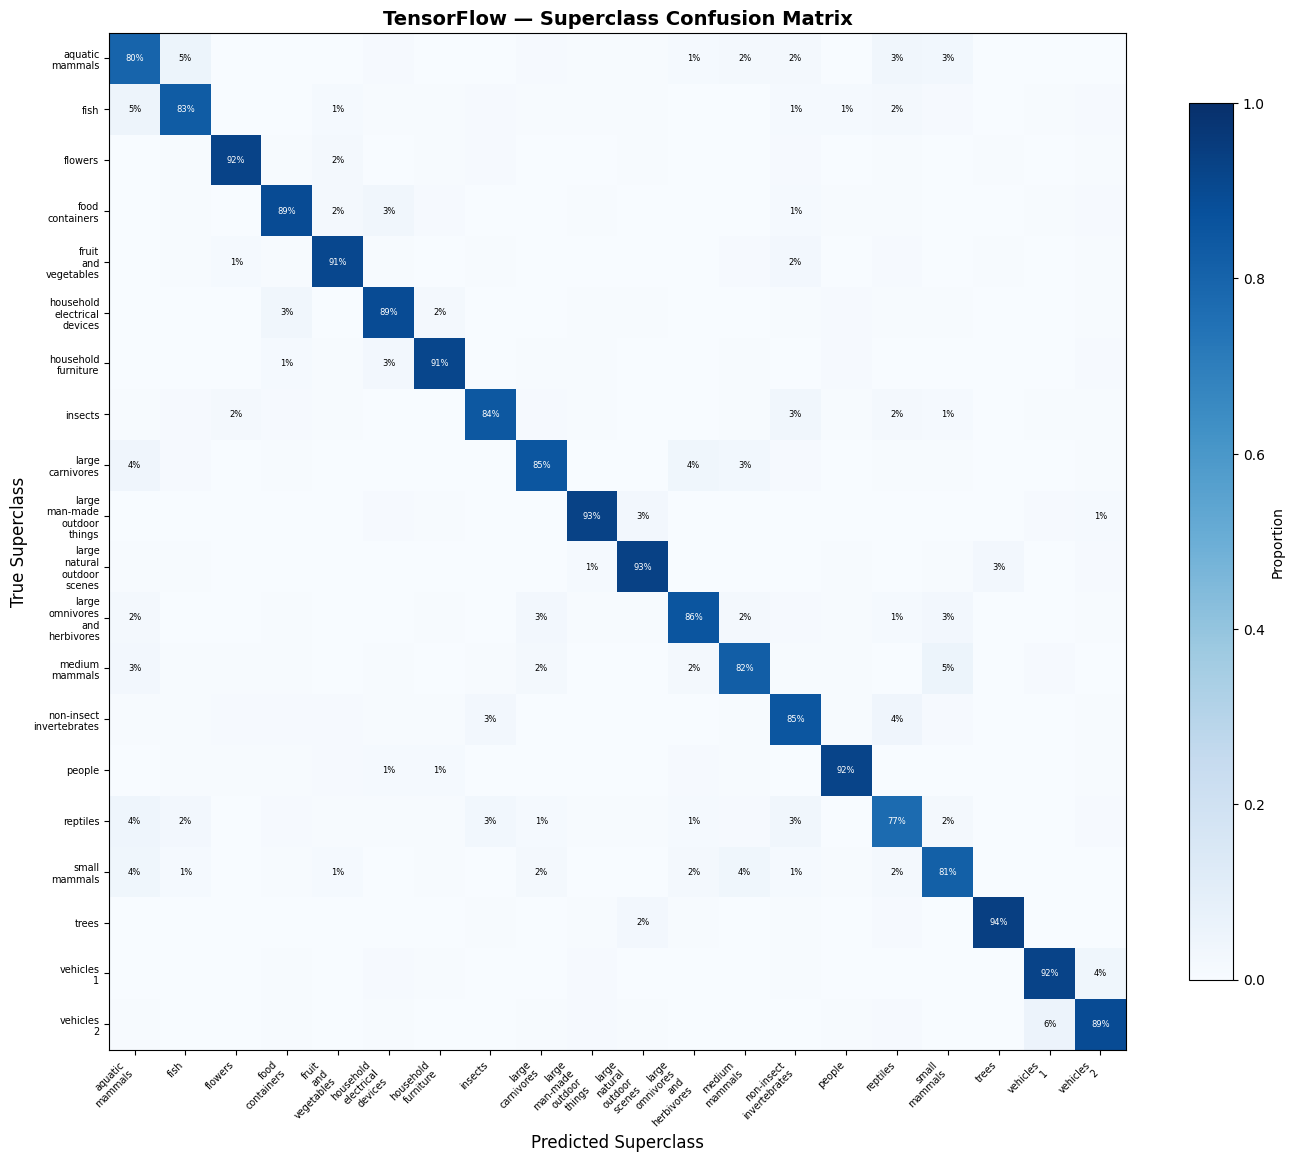


Per-superclass accuracy:
  reptiles                                 77.2%
  aquatic_mammals                          80.0%
  small_mammals                            81.4%
  medium_mammals                           82.4%
  fish                                     83.0%
  insects                                  84.4%
  non-insect_invertebrates                 85.2%
  large_carnivores                         85.2%
  large_omnivores_and_herbivores           85.6%
  vehicles_2                               89.2%
  food_containers                          89.4%
  household_electrical_devices             89.4%
  fruit_and_vegetables                     91.0%
  household_furniture                      91.4%
  people                                   92.0%
  flowers                                  92.2%
  vehicles_1                               92.2%
  large_man-made_outdoor_things            92.8%
  large_natural_outdoor_scenes             93.0%
  trees                                    

In [ ]:
# Step 5: Superclass Confusion Analysis

# Same hierarchical evaluation as PT pipeline
# Compare which superclasses TF struggles with vs PT

print("=" * 60, flush=True)
print("[5/7] Superclass Confusion Analysis", flush=True)
print("=" * 60, flush=True)

# Fine-class and superclass accuracy
fine_acc = float(best_metrics['accuracy'])
pred_coarse = fine_to_coarse[best_preds]
true_coarse = fine_to_coarse[y_test]
superclass_acc = float(np.mean(pred_coarse == true_coarse))

print(f"Fine-class accuracy (100 classes): {fine_acc:.4f}", flush=True)
print(f"Superclass accuracy (20 classes): {superclass_acc:.4f}", flush=True)

# Superclass confusion matrix
plot_superclass_confusion(
    y_true_fine=y_test,
    y_pred_fine=best_preds,
    fine_names=FINE_NAMES,
    coarse_names=COARSE_NAMES,
    fine_to_coarse=fine_to_coarse,
    framework=FRAMEWORK,
    save_path=f'{RESULTS_DIR}/superclass_confusion.png'
)

# Per-fine-class F1
per_class_f1 = []
for c in range(N_CLASSES):
    tp = int(((best_preds == c) & (y_test == c)).sum())
    fp = int(((best_preds == c) & (y_test != c)).sum())
    fn = int(((best_preds != c) & (y_test == c)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    per_class_f1.append((FINE_NAMES[c], f1, COARSE_NAMES[fine_to_coarse[c]]))

per_class_f1.sort(key=lambda x: x[1])

print(f"\n10 Hardest Fine Classes (lowest F1):")
for name, f1, sc in per_class_f1[:10]:
    print(f"  {name:<20} F1={f1:.3f}  (superclass: {sc})")

print(f"\n10 Easiest Fine Classes (highest F1):")
for name, f1, sc in per_class_f1[-10:]:
    print(f"  {name:<20} F1={f1:.3f}  (superclass: {sc})")

In [ ]:
# Step 6: Performance Benchmarks

"""
Inference speed, model size for the ResNet-20 best model
Manual timing with proper batching (avoid OOM)
"""

import time

print("=" * 60)
print("[6/7] Performance Benchmarks")
print("=" * 60)

# Warmup
for ti in range(0, len(X_test), BATCH_SIZE):
    te = min(ti + BATCH_SIZE, len(X_test))
    _ = resnet(X_test[ti:te], training=False)

# Timed runs (10 runs, batched)
n_runs = 10
times = []
for r in range(n_runs):
    start = time.perf_counter()
    for ti in range(0, len(X_test), BATCH_SIZE):
        te = min(ti + BATCH_SIZE, len(X_test))
        _ = resnet(X_test[ti:te], training=False)
    elapsed = time.perf_counter() - start
    times.append(elapsed)

avg_time = sum(times) / len(times)
per_sample_us = (avg_time / len(X_test)) * 1e6
throughput = len(X_test) / avg_time

# Model size — inline calc to avoid util TF dtype issue
model_size = sum(int(np.prod(v.shape)) * 4 for v in resnet.trainable_variables)  # float32 = 4 bytes

print(f"\nModel: ResNet-20 + CutMix + Nesterov SGD")
print(f"Parameters: {n_params_resnet:,}")
print(f"Training time: {perf_resnet['time']:.1f}s ({perf_resnet['time']/60:.1f} min)")
print(f"GPU memory (training): {perf_resnet['gpu_memory']:.2f} MB")
print(f"\nInference ({n_runs} runs averaged):")
print(f"  Total time: {avg_time * 1000:.2f} ms ({len(X_test):,} samples)")
print(f"  Per sample:  {per_sample_us:.2f} us")
print(f"  Throughput:  {throughput:,.0f} samples/sec")
print(f"\nModel size: {model_size / 1024:.2f} KB ({model_size / (1024**2):.2f} MB)")


[6/8] Performance Benchmarks

Model: ResNet-20 + CutMix + Nesterov SGD
Parameters: 4,357,156
Training time: 22367.9s (372.8 min)
GPU memory (training): 3663.97 MB

Inference (10 runs averaged):
  Total time: 2295.37 ms (10,000 samples)
  Per sample:  229.54 us
  Throughput:  4,357 samples/sec

Model size: 16995.64 KB (16.60 MB)


In [ ]:
# Step 7: Save Results

# Save TF ResNet-20 results, compare with PyTorch

print("=" * 60)
print("[7/7] Save Results")
print("=" * 60)

test_metrics = {
    'accuracy': float(best_metrics['accuracy']),
    'macro_f1': float(best_metrics['macro_f1'])
}

# Model size inline (float32 = 4 bytes)
model_size = sum(int(np.prod(v.shape)) * 4 for v in resnet.trainable_variables)

results = build_results_dict(
    framework=FRAMEWORK,
    model_name=MODEL_NAME,
    test_metrics=test_metrics,
    perf=perf_resnet,
    inference_stats={
        'total_time': avg_time,
        'per_sample_us': per_sample_us,
        'samples_per_sec': throughput
    },
    model_size=model_size,
    architecture='ResNet-20 (3 stages, 64-128-256)',
    n_params=int(n_params_resnet),
    epochs=200,
    best_epoch=int(best_epoch),
    optimizer='SGD Nesterov lr=0.05 wd=5e-4',
    augmentation='CutMix + HFlip + RandomCrop',
    lr_schedule='Cosine Annealing (full cycle, no early stop)',
    superclass_accuracy=float(np.mean(fine_to_coarse[best_preds] == fine_to_coarse[y_test])),
    fine_classes=100,
    coarse_classes=20,
    dataset='CIFAR-100',
)

save_results(results, f'{RESULTS_DIR}/tf_cnn_results')
add_result('cnn', results)
print_comparison('cnn')

# Save model weights
resnet.save_weights(f'{RESULTS_DIR}/resnet20_best.weights.h5')
print(f"\nModel saved: {RESULTS_DIR}/resnet20_best.weights.h5")


[7/8] Save Results
    Results saved to: results/tf_cnn_results/metrics.json
    Added 'TensorFlow' to /mnt/c/Users/Max/Desktop/Coding/.Projects/2026/ml-framework-comparisons/data/results/cnn.json
    Frameworks: 2 recorded

CROSS-FRAMEWORK COMPARISON: CNN
Metric                                                                              PyTorch                                                   TensorFlow
--------------------------------------------------------------------------------------------------------------------------------------------------------
model                                                                                   CNN                                                          CNN
training_time                                                                      32.9 min                                                    372.8 min
inference_time_per_sample_us                                                       42.16 µs                                        